In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
import numpy as np


In [39]:

class ResidualBlock(tf.keras.Model):
    def __init__(self, filters, stride=1):
        super().__init__()
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding='same',
                                   use_bias=False)
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, strides=1, padding='same',
                                   use_bias=False)
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.ReLU()

        # Shortcut path
        if stride != 1:
            self.downsample_layer  = tf.keras.Sequential([
                layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False),
                layers.BatchNormalization()
            ])
        else:
            self.downsample_layer = tf.keras.layers.Lambda(lambda x: x)

    def call(self, inputs, training=False):
        residual = self.downsample_layer(inputs)
        x = self.conv1(inputs)
        x = self.bn1(x, training=training)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x, training=training)
        x += residual
        x = self.relu(x)
        return x


In [48]:

def Mini_ResNet_Model(num_classes=10):
    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(32, 3, strides=1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Stage 1
    x = ResidualBlock(32, stride=1)(x)
    x = ResidualBlock(32, stride=1)(x)

    # Stage 2
    x = ResidualBlock(64, stride=2)(x)
    x = ResidualBlock(64, stride=1)(x)

    # Stage 3
    x = ResidualBlock(128, stride=2)(x)
    x = ResidualBlock(128, stride=1)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

In [49]:

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train.astype("float32") / 255.0, x_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()

In [50]:

model = Mini_ResNet_Model(num_classes=10)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_48 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_39               │ (None, 32, 32, 32)     │        18,688 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_40               │ (None, 32, 32, 32)     │        18,688 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_41               │ (None, 16, 16, 64)     │        58,112 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_42               │ (None, 16, 16, 64)     │        74,240 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_43               │ (None, 8, 8, 128)      │       230,912 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_44               │ (None, 8, 8, 128)      │       295,936 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,402 (2.73 MB)

 Trainable params: 713,162 (2.72 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [51]:

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=128
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.4318 - loss: 1.5474 - val_accuracy: 0.3992 - val_loss: 1.8883
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6856 - loss: 0.8828 - val_accuracy: 0.5072 - val_loss: 1.5811
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.7619 - loss: 0.6791 - val_accuracy: 0.7251 - val_loss: 0.8031
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8086 - loss: 0.5412 - val_accuracy: 0.6757 - val_loss: 0.9897
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.8415 - loss: 0.4505 - val_accuracy: 0.6576 - val_loss: 1.0822
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8739 - loss: 0.3686 - val_accuracy: 0.6091 - val_loss: 1.3059
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8945 - loss: 0.3049 - val_accuracy: 0.7375 - val_loss: 0.8148
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9123 - loss: 0.2487 - 

In [52]:

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n✅ Test accuracy: {test_acc * 100:.2f}%")

313/313 - 2s - 7ms/step - accuracy: 0.7919 - loss: 1.0332

✅ Test accuracy: 79.19%


In [53]:
import matplotlib.pyplot as plt
import numpy as np

In [54]:
def plot_training_curves(history):
    """Plot training & validation accuracy and loss."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Accuracy Plot
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss Plot
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

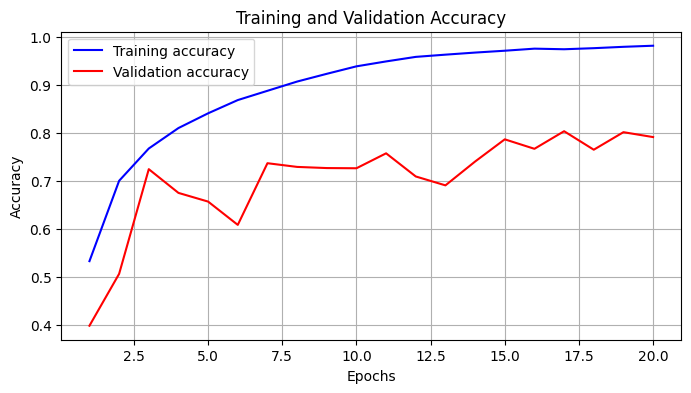

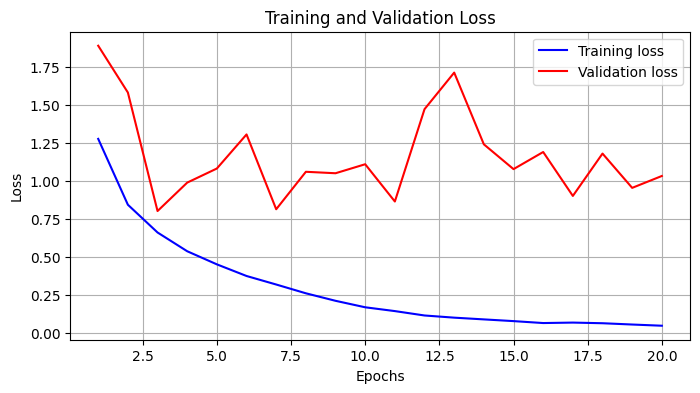

In [55]:
plot_training_curves(history)